# HistGradientBoosting Baseline - PS-S06E08

This notebook implements a **HistGradientBoostingClassifier** model for **Playground Series – Season 6, Episode 8: Predicting Smartphone Addiction**.

We employ Stratified 5-Fold cross-validation, multi-seed training, and out-of-fold probability exporting to feed into the 4-Model Stacking Ensemble.

## 1. Setup & Imports

In [1]:
import os
import gc
import sys
import json
import math
import time
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

from ps_s06e08_experiment_setup import ExperimentSetup
from ps_s06e08_feature_engineering import FeatureFactory
from ps_s06e08_model_visualizer import ModelVisualizer

warnings.filterwarnings('ignore')
%matplotlib inline

## 2. Configuration & Experiment Setup

In [2]:
MODEL_PREFIX = "hgb"
N_SPLITS = 5

setup = ExperimentSetup(
    model_name='HistGradientBoosting',
    use_gpu=False,
    perform_rfe=False,
    perform_optuna_tuning=False
)

seeds = setup.seed()
setup.configure_pandas()
setup.suppress_warnings()

Warnings suppressed.


## 3. Data Loading & Feature Engineering

In [3]:
train_df = setup.read_dataset('training')
test_df = setup.read_dataset('test')
print(f"Raw Train shape: {train_df.shape}, Test shape: {test_df.shape}")

# HistGradientBoosting achieves best performance on raw categorical-encoded features
fe_strategies = ['encoding']

factory = FeatureFactory(strategies=fe_strategies)
factory.fit(train_df)
X = factory.transform(train_df)
y = train_df['addicted_label']
X_test = factory.transform(test_df)
print(f"Engineered Train shape: {X.shape}, Test shape: {X_test.shape}")

# Ensure categorical columns are properly categorized for HistGradientBoosting
categorical_cols = ['gender', 'stress_level', 'academic_work_impact']
for c in categorical_cols:
    if c in X.columns:
        X[c] = X[c].astype('category')
        X_test[c] = X_test[c].astype('category')

TRAINING DATASET

   id    age  daily_screen_time_hours  social_media_hours  gaming_hours  \
0   0 24.000                      NaN               1.830         1.590   
1   1 19.000                    5.970               1.080           NaN   
2   2 18.000                    5.090                 NaN           NaN   
3   3 21.000                    6.420               1.260         1.420   
4   4 26.000                   11.200               1.870         2.810   

   work_study_hours  sleep_hours  notifications_per_day  app_opens_per_day  \
0             2.110        7.460                122.000             38.000   
1             3.030        8.220                 76.000             19.000   
2               NaN        6.250                134.000             60.000   
3             3.360        8.850                112.000             94.000   
4             1.950        5.250                    NaN                NaN   

   weekend_screen_time  gender stress_level academic_work_impa

## 4. Multi-Seed 5-Fold Model Training

In [4]:
hgb_params = {
    'max_iter': 1000,
    'learning_rate': 0.08,
    'max_depth': 6,
    'l2_regularization': 1.0,
    'categorical_features': categorical_cols,
    'early_stopping': True,
    'n_iter_no_change': 30
}

seed_oof_preds = []
seed_test_preds = []
seed_scores = []

for seed_idx, seed in enumerate(seeds):
    print(f"\n================ SEED RUN {seed_idx+1}/{len(seeds)}: seed={seed} ================")
    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=seed)
    oof_probs = np.zeros(len(train_df))
    test_probs = np.zeros(len(test_df))
    
    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
        X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
        X_val, y_val = X.iloc[val_idx], y.iloc[val_idx]
        
        model = HistGradientBoostingClassifier(**hgb_params, random_state=seed + fold)
        model.fit(X_train, y_train)
        
        val_pred = model.predict_proba(X_val)[:, 1]
        oof_probs[val_idx] = val_pred
        test_probs += model.predict_proba(X_test)[:, 1] / N_SPLITS
        
        fold_auc = roc_auc_score(y_val, val_pred)
        print(f"  Fold {fold+1} ROC AUC: {fold_auc:.6f}")
        
    seed_auc = roc_auc_score(y, oof_probs)
    print(f"--- Seed {seed} CV ROC AUC: {seed_auc:.6f} ---")
    seed_oof_preds.append(oof_probs)
    seed_test_preds.append(test_probs)
    seed_scores.append(seed_auc)

final_oof_probs = np.mean(seed_oof_preds, axis=0)
final_test_probs = np.mean(seed_test_preds, axis=0)
final_cv_auc = roc_auc_score(y, final_oof_probs)

print("\n" + "="*60)
print(f"HistGradientBoosting Seed-Averaged CV ROC AUC: {final_cv_auc:.6f}")
print("="*60)


================ SEED RUN 1/5: seed=10301 ================
  Fold 1 ROC AUC: 0.962742
  Fold 2 ROC AUC: 0.963250
  Fold 3 ROC AUC: 0.963642
  Fold 4 ROC AUC: 0.963408
  Fold 5 ROC AUC: 0.963195
--- Seed 10301 CV ROC AUC: 0.963246 ---

================ SEED RUN 2/5: seed=42 ================
  Fold 1 ROC AUC: 0.962738
  Fold 2 ROC AUC: 0.963127
  Fold 3 ROC AUC: 0.963335
  Fold 4 ROC AUC: 0.964021
  Fold 5 ROC AUC: 0.962932
--- Seed 42 CV ROC AUC: 0.963229 ---

================ SEED RUN 3/5: seed=2026 ================
  Fold 1 ROC AUC: 0.962374
  Fold 2 ROC AUC: 0.963937
  Fold 3 ROC AUC: 0.964026
  Fold 4 ROC AUC: 0.963457
  Fold 5 ROC AUC: 0.962540
--- Seed 2026 CV ROC AUC: 0.963264 ---

================ SEED RUN 4/5: seed=777 ================
  Fold 1 ROC AUC: 0.963565
  Fold 2 ROC AUC: 0.963586
  Fold 3 ROC AUC: 0.963585
  Fold 4 ROC AUC: 0.962825
  Fold 5 ROC AUC: 0.962607
--- Seed 777 CV ROC AUC: 0.963233 ---

================ SEED RUN 5/5: seed=888 ================
  Fold 1 ROC A

## 5. Model Diagnostics & Visualization

<Figure size 800x600 with 0 Axes>

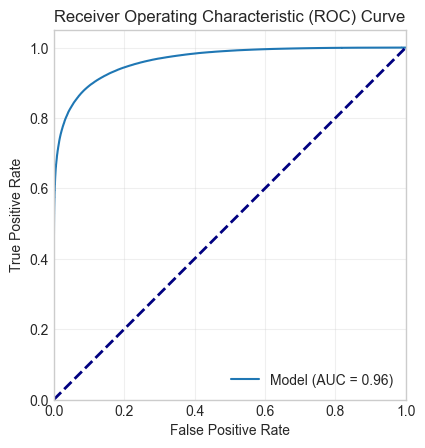

Confusion matrix, without normalization


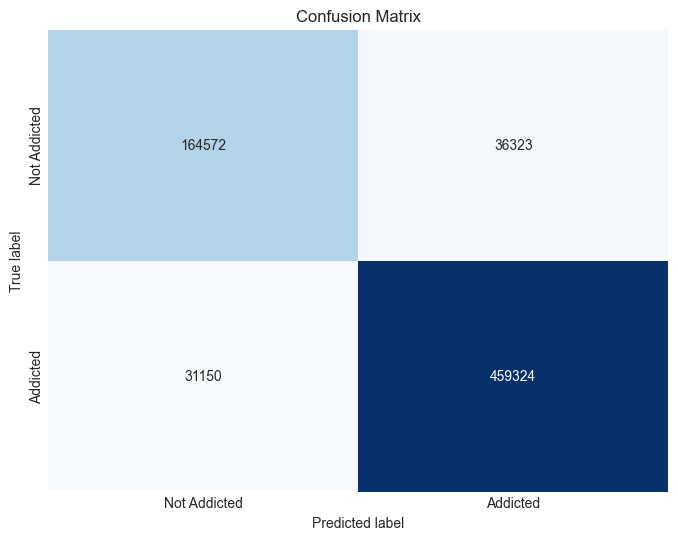

In [5]:
visualizer = ModelVisualizer(model_name="HistGradientBoosting")
visualizer.plot_roc_curve(y_true=y, y_score=final_oof_probs)
visualizer.plot_confusion_matrix(y_true=y, y_pred=(final_oof_probs >= 0.5).astype(int), classes=['Not Addicted', 'Addicted'])

## 6. Saving OOF, Test Probabilities & Submission File

In [6]:
submission_df = setup.read_dataset('submission')
submission_df['addicted_label'] = final_test_probs
submission_df.to_csv('submission.csv', index=False)
print("Saved submission.csv successfully!")

oof_probs_2d = np.column_stack([1 - final_oof_probs, final_oof_probs])
test_probs_2d = np.column_stack([1 - final_test_probs, final_test_probs])
filled_mask = np.ones(len(train_df), dtype=bool)

setup.save_probabilities(MODEL_PREFIX, oof_probs_2d, train_df['id'], y, filled_mask, test_probs_2d, test_df['id'])

Saved submission.csv successfully!
Saved for ensembling:
 - predictions/hgb_oof_probs.csv
 - predictions/hgb_test_probs.csv
